# Insurance

In [239]:
import pandas as pd
import numpy as np

In [240]:
df_input = pd.read_csv("insurance.csv")
df_input.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Understanding Data

In [241]:
df_input.shape

(1338, 7)

In [242]:
df_input.sample(5)

,age,sex,bmi,children,smoker,region,charges
329,52,male,36.700,0,no,southwest,9144.56500
947,37,male,34.200,1,yes,northeast,39047.28500
292,25,male,45.540,2,yes,southeast,42112.23560
35,19,male,20.425,0,no,northwest,1625.43375
1120,23,female,31.400,0,yes,southwest,34166.27300


In [243]:
df_input.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [244]:
df_input.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [245]:
df_input.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [246]:
df_input.duplicated().sum()

np.int64(1)

## EDA 

### Univariate Analysis - Categorical Data

In [247]:
df_input.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [248]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='sex'>

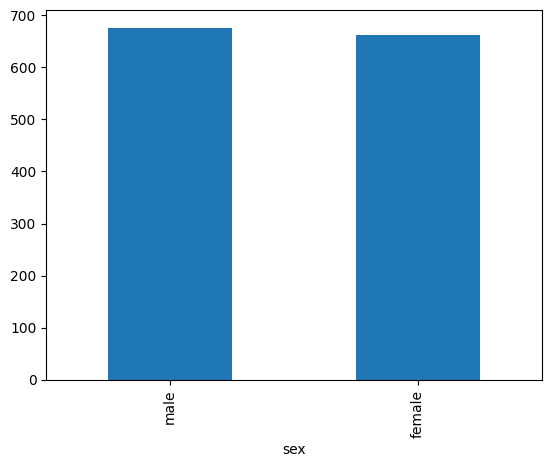

In [249]:
df_input['sex'].value_counts().plot(kind='bar')

<Axes: xlabel='sex', ylabel='count'>

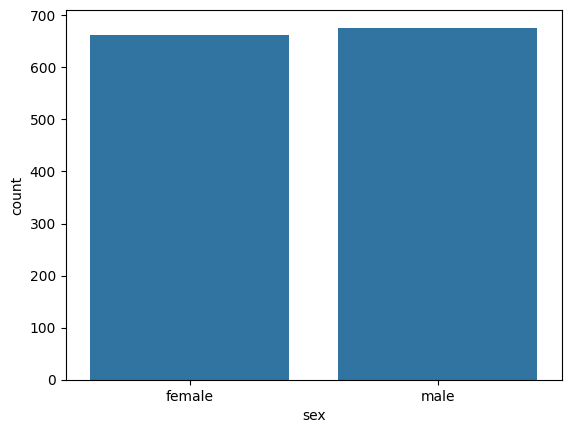

In [250]:
sns.countplot(data=df_input, x='sex')

<Axes: >

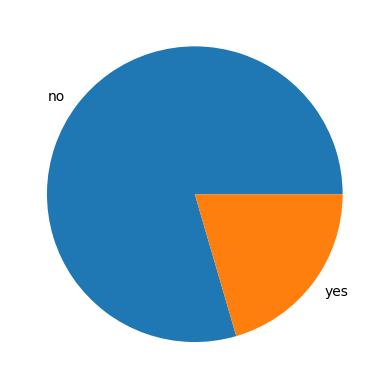

In [251]:
df_input['smoker'].value_counts().plot(kind='pie')

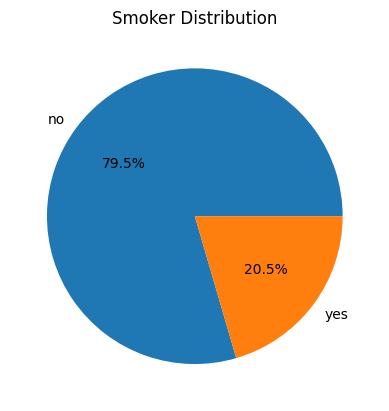

In [252]:
smoker_counts = df_input['smoker'].value_counts()

plt.pie(smoker_counts, labels=smoker_counts.index, autopct='%1.1f%%')

plt.title("Smoker Distribution")
plt.show()

<Axes: xlabel='region', ylabel='count'>

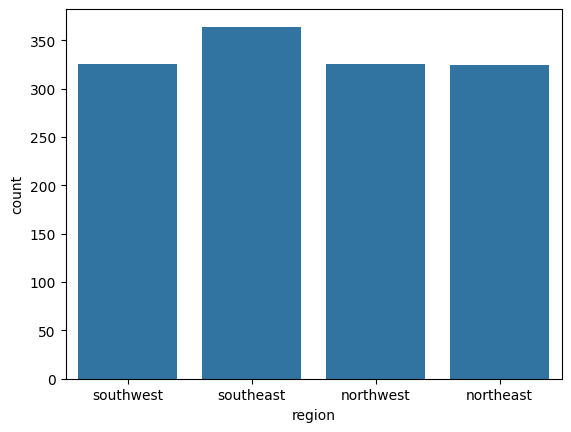

In [253]:
sns.countplot(data=df_input, x='region')

### Univariate Analysis - Numerical Data

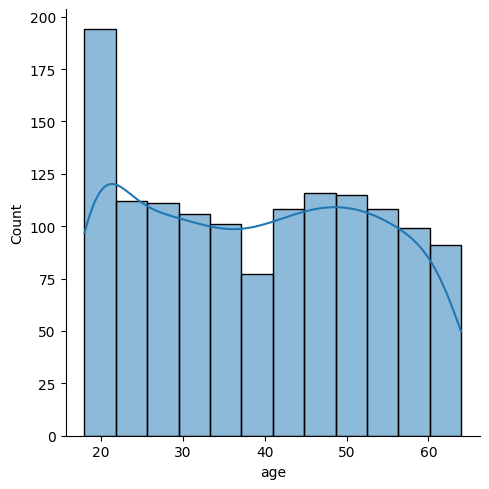

In [254]:
sns.displot(data=df_input, x='age', kde=True)

<Axes: xlabel='charges', ylabel='Density'>

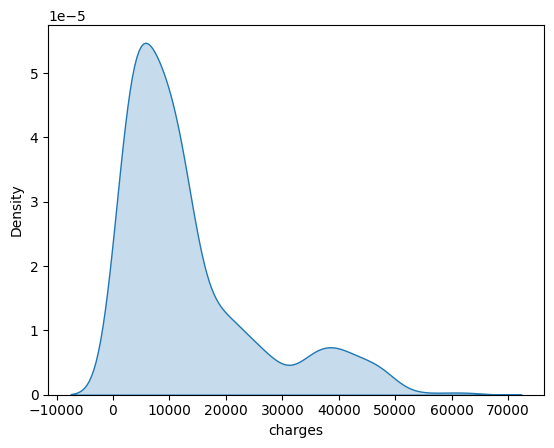

In [255]:
sns.kdeplot(data=df_input, x='charges', fill=True)

<Axes: xlabel='bmi', ylabel='Density'>

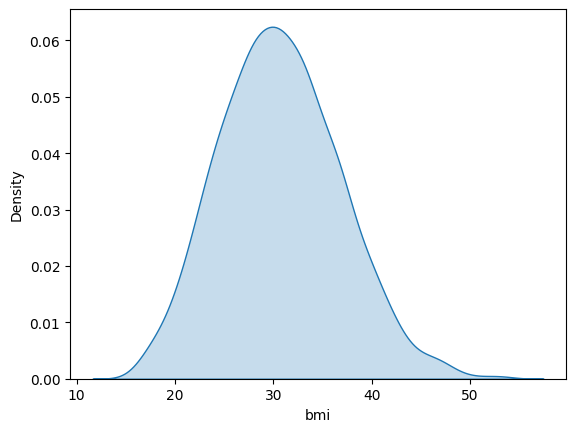

In [256]:
sns.kdeplot(data=df_input, x='bmi', fill=True)

<Axes: xlabel='charges'>

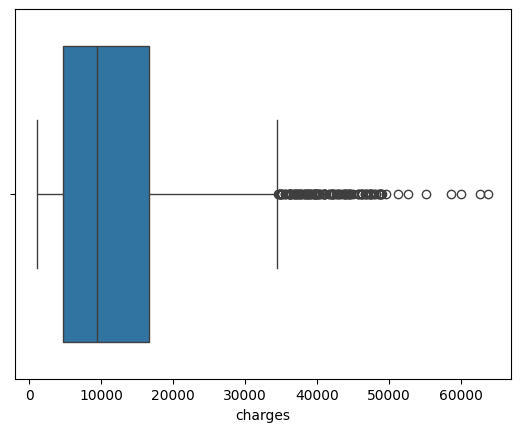

In [257]:
sns.boxplot(data=df_input, x='charges')

<Axes: xlabel='age'>

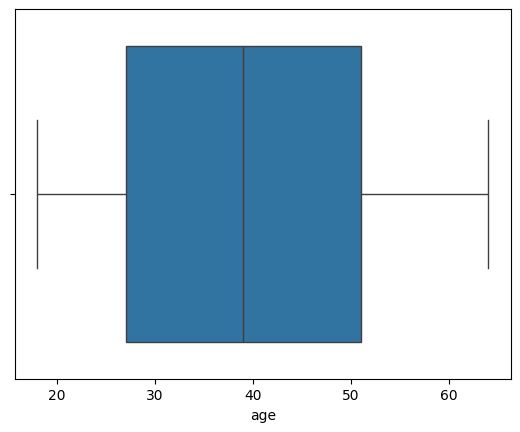

In [258]:
sns.boxplot(data=df_input, x='age')

In [259]:
print(df_input.shape)
df_input.drop_duplicates(inplace=True)
print(df_input.shape)

(1338, 7)
(1337, 7)


In [260]:
df_input['charges'].describe()

count     1337.000000
mean     13279.121487
std      12110.359656
min       1121.873900
25%       4746.344000
50%       9386.161300
75%      16657.717450
max      63770.428010
Name: charges, dtype: float64

In [261]:
df_input['age'].describe()

count    1337.000000
mean       39.222139
std        14.044333
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

## Bivariate Analysis & Multivariate Analysis

In [262]:
df_input.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


<Axes: xlabel='age', ylabel='charges'>

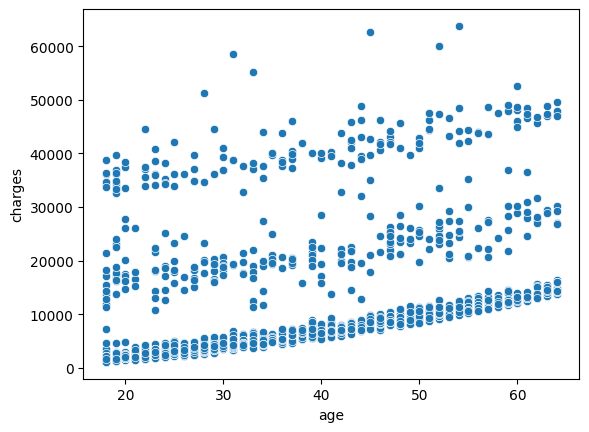

In [263]:
sns.scatterplot(data=df_input, x='age', y='charges')

<Axes: xlabel='age', ylabel='charges'>

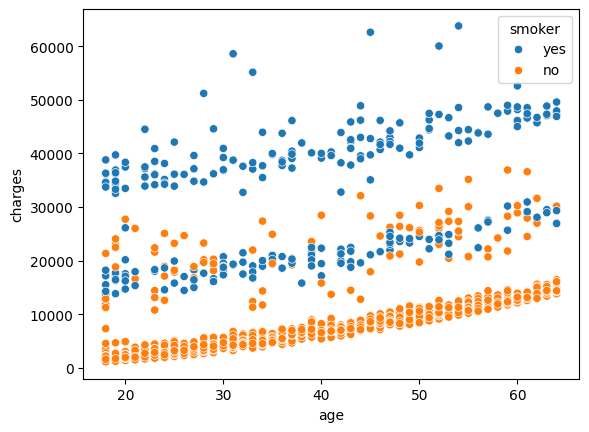

In [264]:
sns.scatterplot(data=df_input, x='age', y='charges', hue='smoker')

<Axes: xlabel='age', ylabel='charges'>

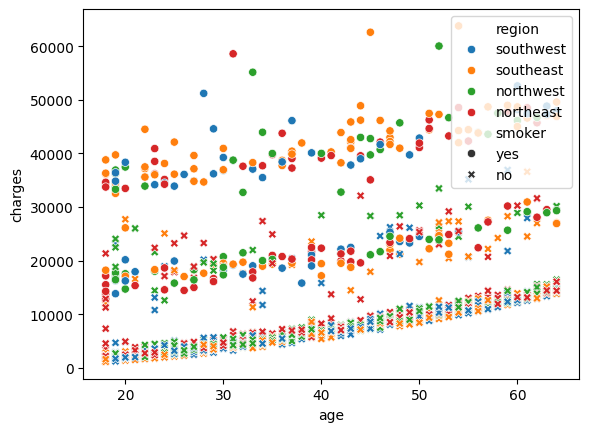

In [265]:
sns.scatterplot(data=df_input, x='age', y='charges', hue='region', style='smoker')

<Axes: xlabel='sex', ylabel='age'>

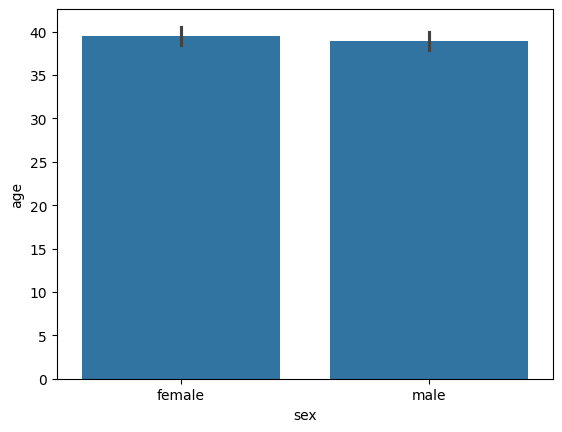

In [266]:
sns.barplot(data=df_input, x='sex', y='age')

<Axes: xlabel='sex', ylabel='age'>

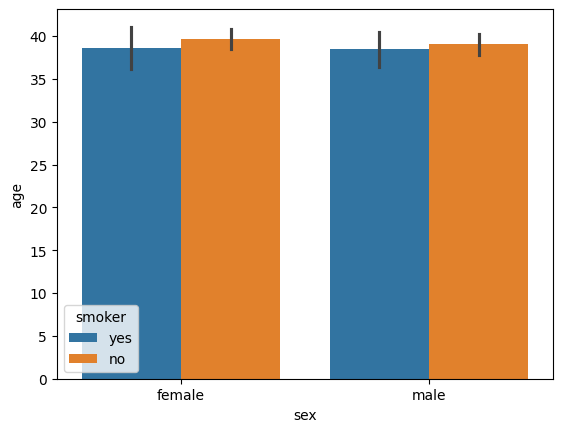

In [267]:
sns.barplot(data=df_input, x='sex', y='age', hue='smoker')

<Axes: xlabel='sex', ylabel='charges'>

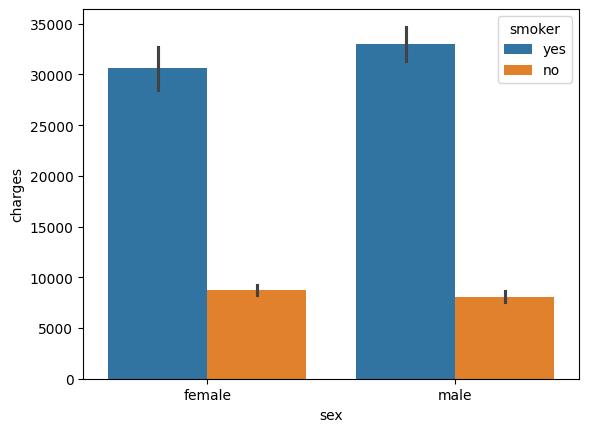

In [268]:
sns.barplot(data=df_input, x='sex', y='charges', hue='smoker')

<Axes: >

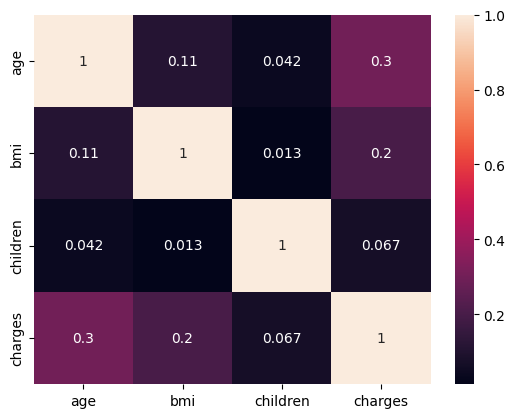

In [269]:
sns.heatmap(df_input.corr(numeric_only=True), annot=True)

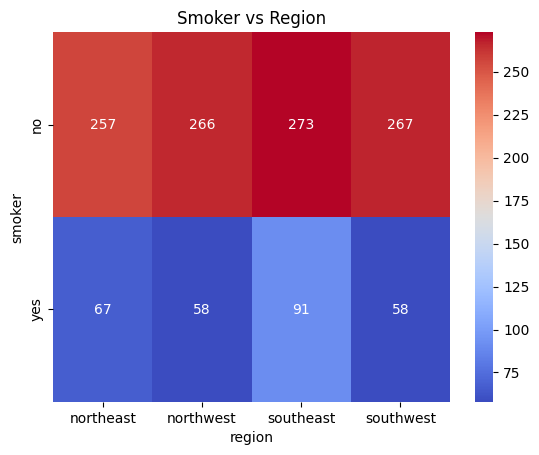

In [270]:
ct = pd.crosstab(df_input['smoker'], df_input['region'])

sns.heatmap(ct, annot=True, cmap='coolwarm', fmt='d')

plt.title("Smoker vs Region")
plt.show()

<Axes: xlabel='region', ylabel='smoker'>

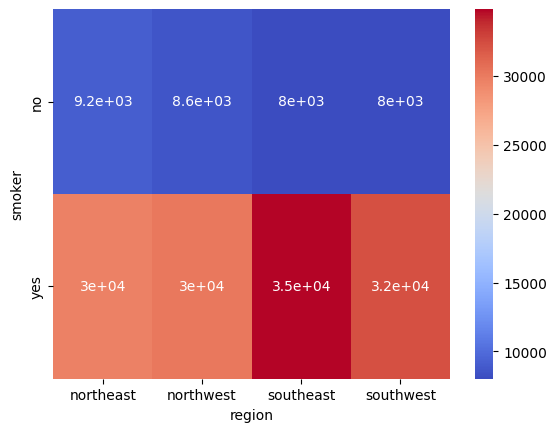

In [271]:
pt = df_input.pivot_table(index='smoker', columns='region', values='charges', aggfunc='mean')

sns.heatmap(pt, annot=True, cmap='coolwarm')

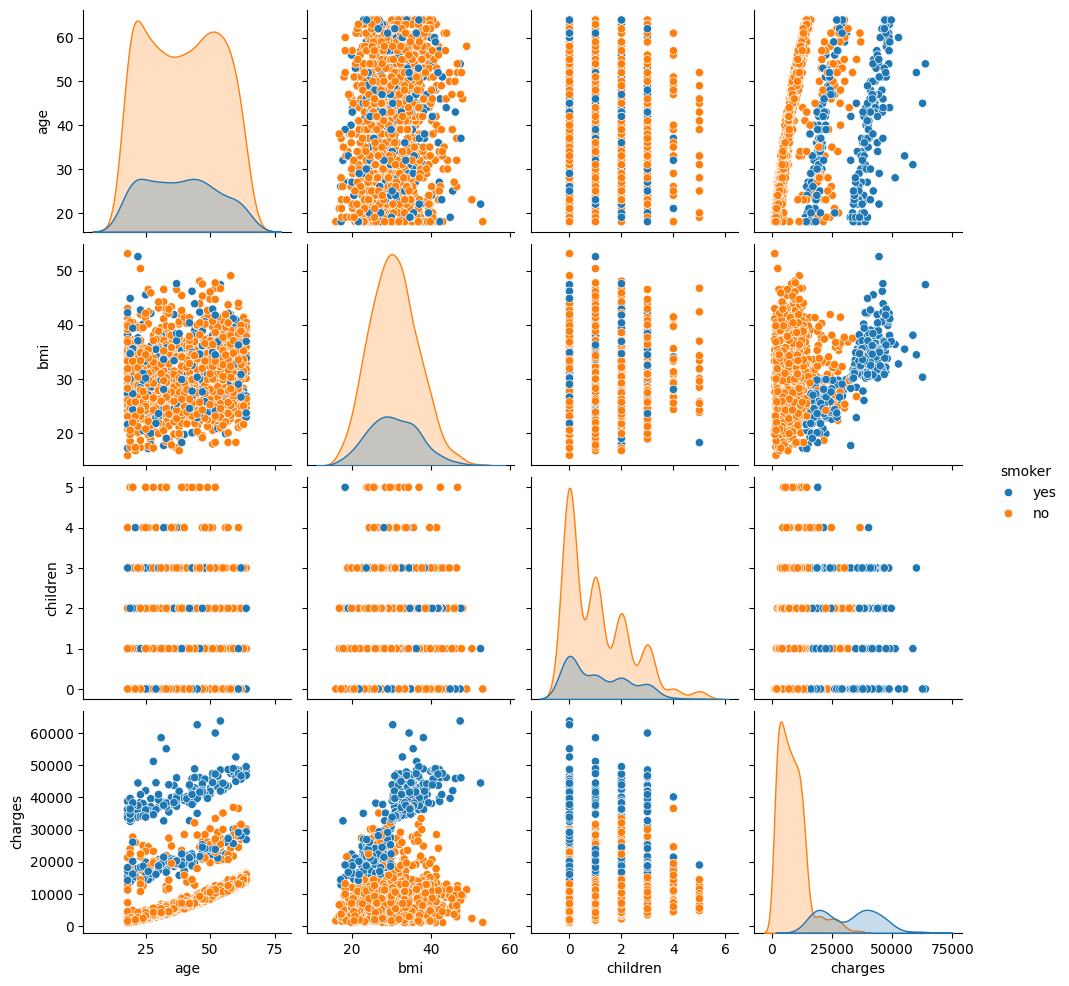

In [272]:
sns.pairplot(data=df_input, hue='smoker')

## Feature Engineering and Pipeline

In [273]:
df_input.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [274]:
from sklearn.model_selection import train_test_split

from sklearn import set_config
set_config(display='diagram')

In [275]:
X = df_input.drop(columns='charges')
y = df_input['charges']

X.head()

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest


In [276]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [277]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

num_col = ['age', 'bmi', 'children']
str_col = ['sex', 'smoker', 'region']

pre_processor = ColumnTransformer([
    ('num', StandardScaler(), num_col),
    ('str', OneHotEncoder(drop='first'), str_col)
])

In [278]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

pipe = Pipeline([
    ('pre_processor', pre_processor),
    ('model', LinearRegression())
])

In [279]:
X_train

,age,sex,bmi,children,smoker,region
1114,23,male,24.510,0,no,northeast
968,21,male,25.745,2,no,northeast
599,52,female,37.525,2,no,northwest
170,63,male,41.470,0,no,southeast
275,47,female,26.600,2,no,northeast
...,...,...,...,...,...,...
1096,51,female,34.960,2,yes,northeast
1131,27,male,45.900,2,no,southwest
1295,20,male,22.000,1,no,southwest
861,38,female,28.000,3,no,southwest


In [280]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre_processor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('str', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [281]:
y_pred = pipe.predict(X_test)

In [282]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))


R2 Score: 0.8069287081198012
MAE: 4177.045561036326


In [283]:
from sklearn.ensemble import RandomForestRegressor

In [284]:
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)

In [285]:
rf_pipe = Pipeline([
    ('pre_processor', pre_processor),
    ('rf', rf)
])

In [286]:
rf_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre_processor', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('str', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [287]:
y_pred_rf = rf_pipe.predict(X_test)

In [288]:
print("R2 Score:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))

R2 Score: 0.8826342386758796
MAE: 2621.507603919745


In [289]:
pipe.named_steps

{'pre_processor': ColumnTransformer(transformers=[('num', StandardScaler(),
                                  ['age', 'bmi', 'children']),
                                 ('str', OneHotEncoder(drop='first'),
                                  ['sex', 'smoker', 'region'])]),
 'model': LinearRegression()}

In [290]:
rf_pipe.named_steps

{'pre_processor': ColumnTransformer(transformers=[('num', StandardScaler(),
                                  ['age', 'bmi', 'children']),
                                 ('str', OneHotEncoder(drop='first'),
                                  ['sex', 'smoker', 'region'])]),
 'rf': RandomForestRegressor(max_depth=10, random_state=42)}

In [291]:
coefficients = pipe.named_steps['model'].coef_

In [292]:
rf_pipe.named_steps['rf'].feature_importances_

array([0.13420161, 0.2120084 , 0.02176698, 0.00609601, 0.61055853,
       0.00595822, 0.00532323, 0.00408701])

In [293]:
# from sklearn.preprocessing import StandardScaler, OneHotEncoder
# from sklearn.compose import ColumnTransformer

# num_cols = ['age', 'bmi', 'children']
# cat_cols = ['sex', 'smoker', 'region']

# pre_processor = ColumnTransformer([
#     ('num', StandardScaler(), num_cols),
#     ('cat', OneHotEncoder(drop='first'), cat_cols)
# ])

In [294]:
# from sklearn.pipeline import Pipeline
# from sklearn.linear_model import LinearRegression

# pipe = Pipeline([
#     ('pre_processor', pre_processor),
#     ('model', LinearRegression())
# ])

In [295]:
# pipe.fit(X_train, y_train)

In [311]:
coefficients = pipe.named_steps['model'].coef_

In [312]:
import pandas as pd

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

print(feat_imp)

                 Feature   Coefficient
4        str__smoker_yes  23077.764593
0               num__age   3472.975553
1               num__bmi   1927.828251
2          num__children    636.501185
3          str__sex_male   -101.542054
5  str__region_northwest   -391.761455
7  str__region_southwest   -659.139752
6  str__region_southeast   -838.919616


In [299]:
import shap

In [315]:
X_train_transformed = pipe.named_steps['pre_processor'].transform(X_train)

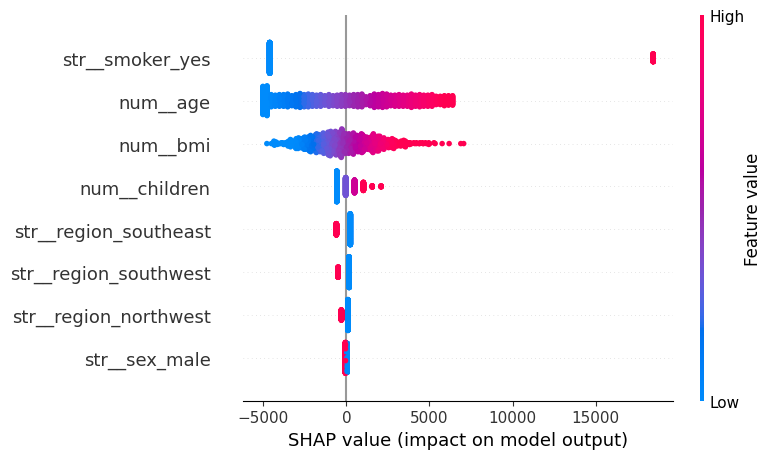

In [316]:
explainer = shap.LinearExplainer(
    pipe.named_steps['model'],
    X_train_transformed
)

shap_values = explainer.shap_values(X_train_transformed)

shap.summary_plot(shap_values, X_train_transformed, feature_names=feature_names)

In [317]:
import joblib

joblib.dump(pipe, 'insurance_model.pkl')

['insurance_model.pkl']

In [318]:
model = joblib.load('insurance_model.pkl')

In [319]:
import pandas as pd

sample = pd.DataFrame({
    'age': [30],
    'sex': ['male'],
    'bmi': [25],
    'children': [1],
    'smoker': ['no'],
    'region': ['southwest']
})

prediction = model.predict(sample)
print("Predicted Charges:", prediction[0])

Predicted Charges: 4093.533517859353
